# TASK #1: UNDERSTAND THE PROBLEM STATEMENT  

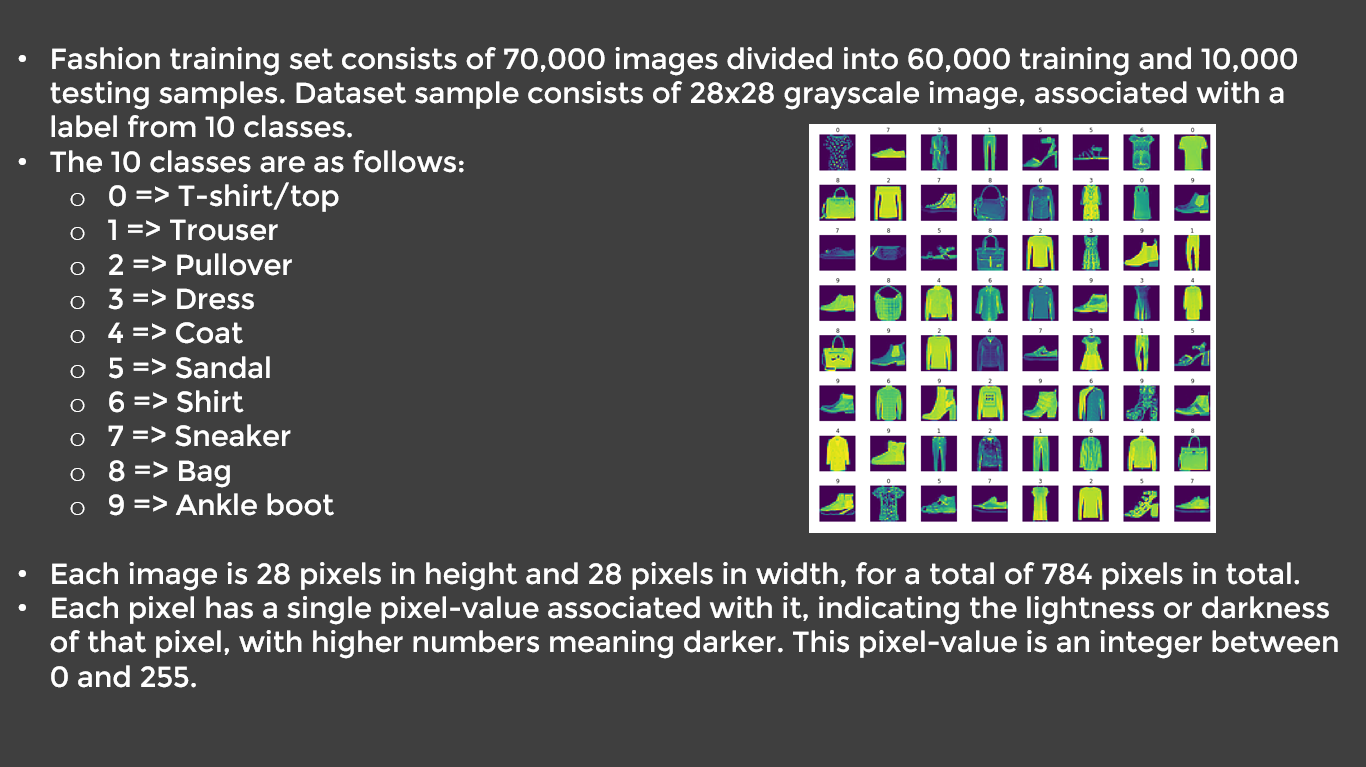

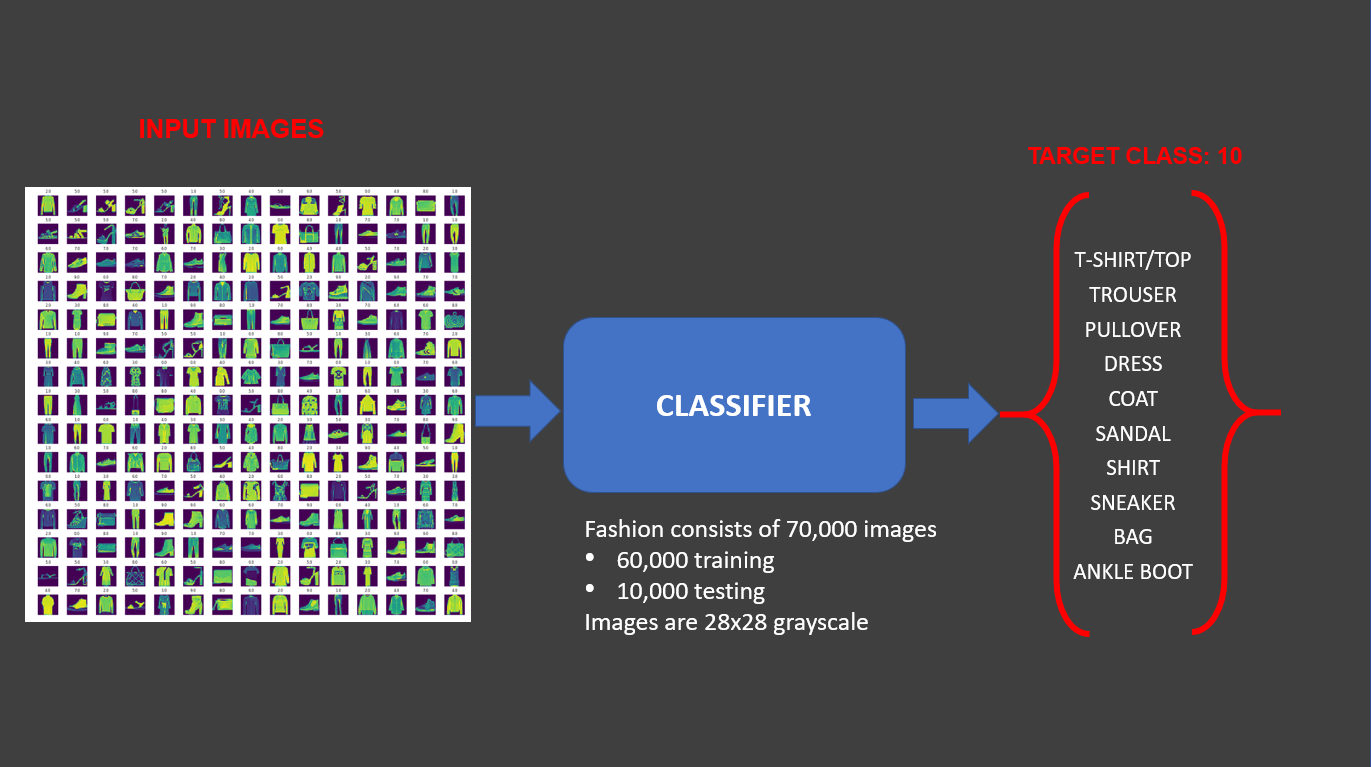

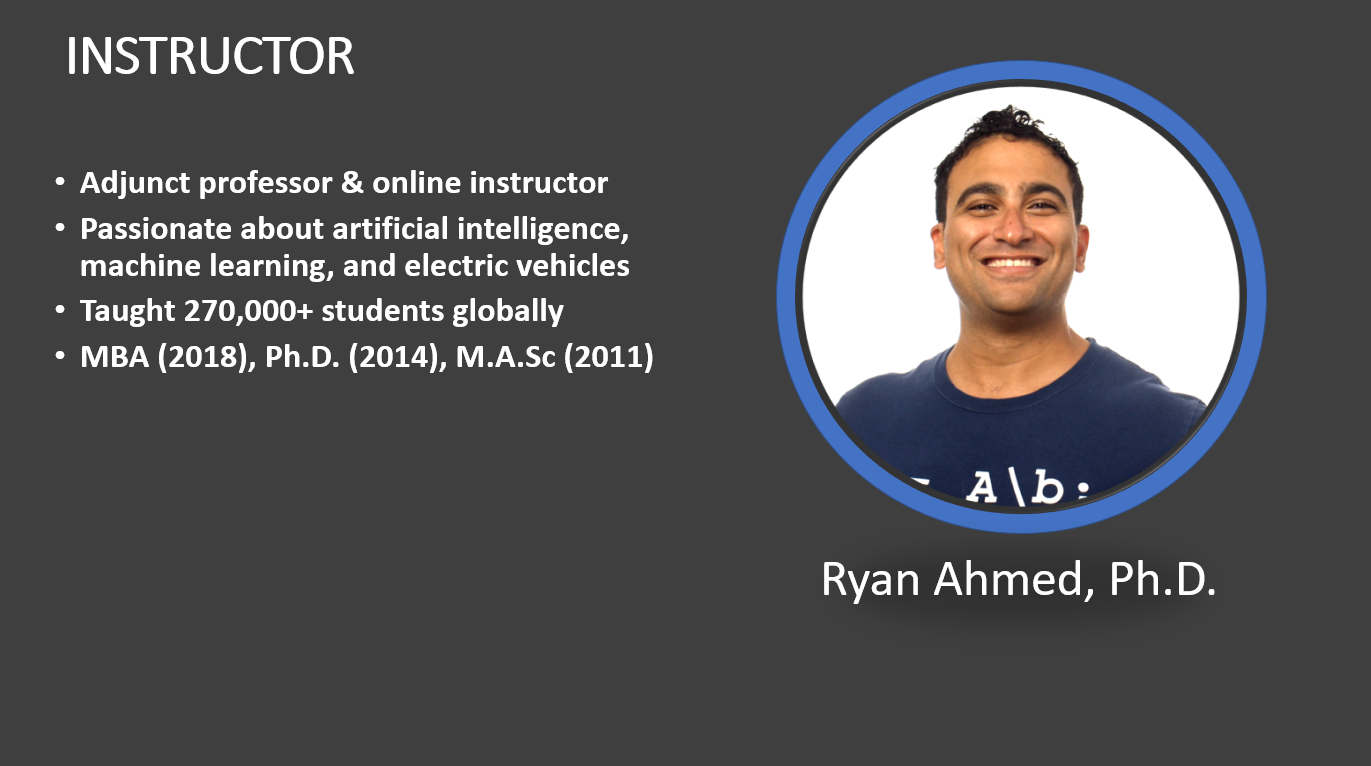

# TASK #2: IMPORT LIBRARIES AND DATASETS

In [40]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random 


import matplotlib.pyplot as plt
from jupyterthemes import jtplot
jtplot.style(theme = 'monokai', context = 'notebook', ticks = True, grid = False) 
# setting the style of the notebook to be monokai theme  
# this line of code is important to ensure that we are able to see the x and y axes clearly
# If you don't run this code line, you will notice that the xlabel and ylabel on any plot is black on black and it will be hard to see them. 


In [41]:
# Use the same dataset made readily available by keras Using the following lines of code:
(X_train, y_train) , (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()


**PRACTICE OPPORTUNITY #1:**
- **Check out the sizes of both training and testing datasets**

In [42]:
print(f'x_train shape: {X_train.shape}, y_train shape: {y_train.shape}')
print(f'x_test shape: {X_test.shape}, y_test shape: {y_test.shape}')

x_train shape: (60000, 28, 28), y_train shape: (60000,)
x_test shape: (10000, 28, 28), y_test shape: (10000,)


# TASK #3: PERFORM DATA VISUALIZATION

5


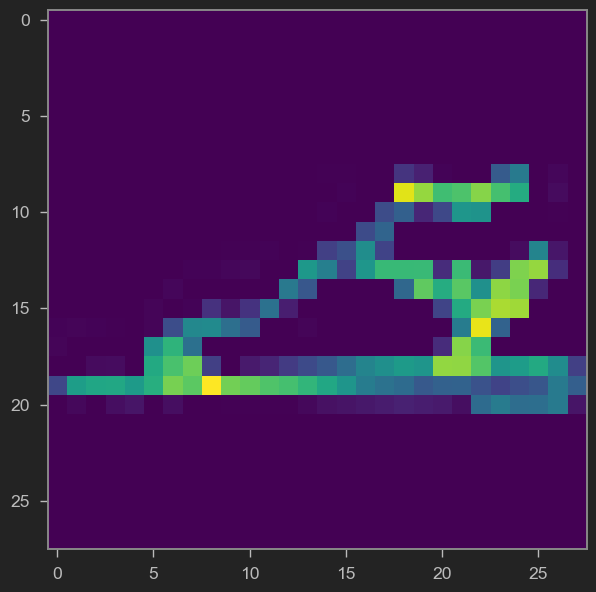

In [43]:
# Select a sample image and visualize it
i = 300
plt.imshow(X_train[i])
print(y_train[i])

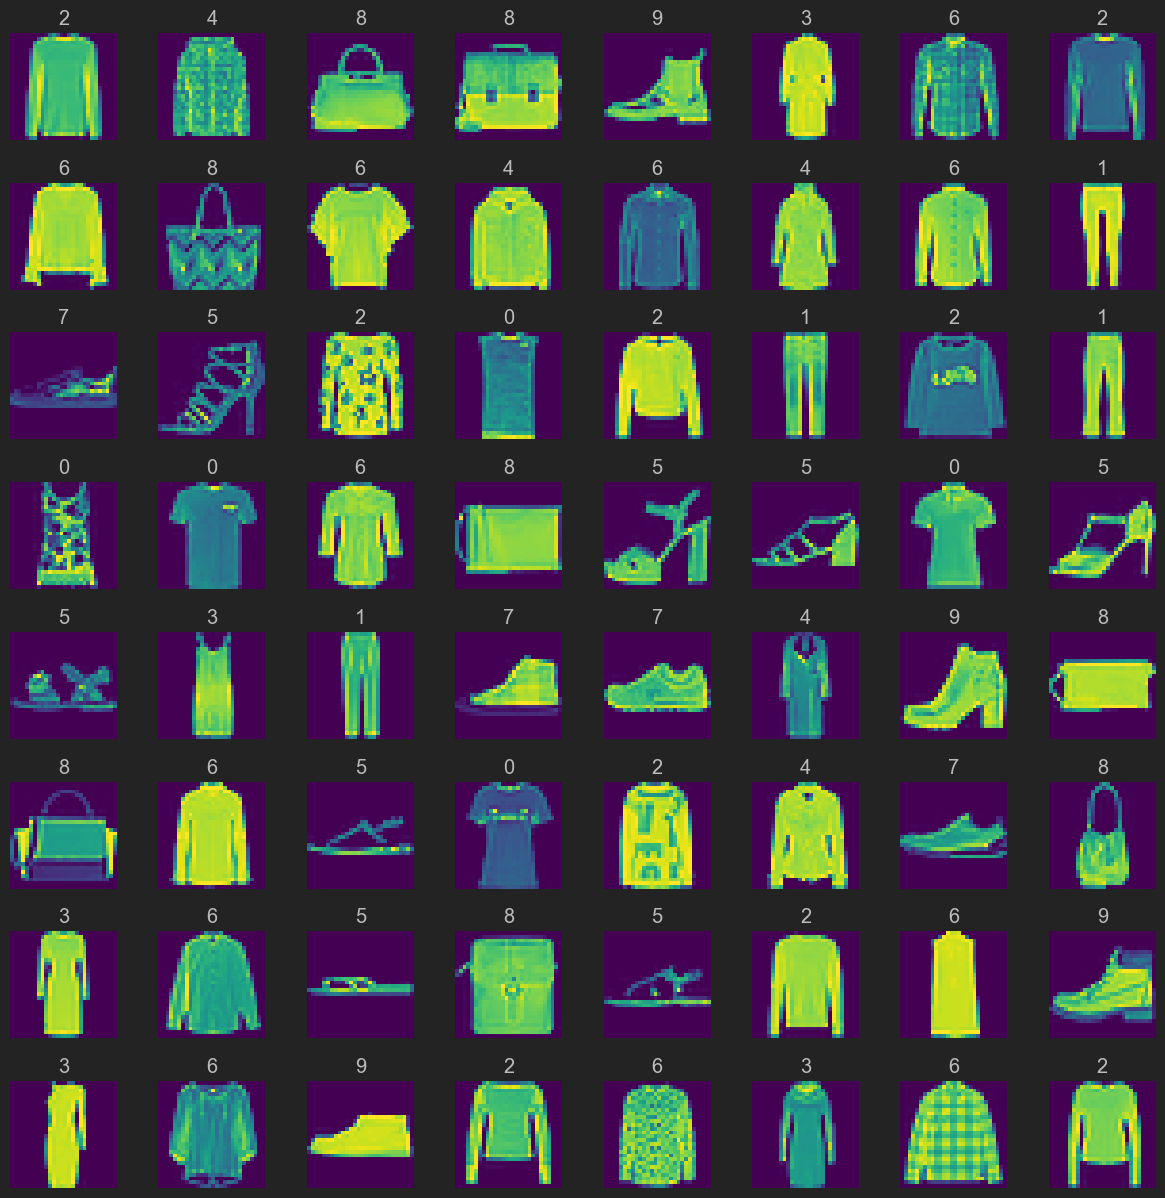

In [44]:
# Remember the 10 classes decoding is as follows:
# 0 => T-shirt/top
# 1 => Trouser
# 2 => Pullover
# 3 => Dress
# 4 => Coat
# 5 => Sandal
# 6 => Shirt
# 7 => Sneaker
# 8 => Bag
# 9 => Ankle boot


W_grid = 8
L_grid = 8

fig, axes = plt.subplots(L_grid, W_grid, figsize = (15, 15))
axes = axes.ravel()

n_training = len(X_train)

for i in np.arange(0, L_grid * W_grid):
    index = np.random.randint(0, n_training) # pick a random number
    axes[i].imshow(X_train[index])
    axes[i].set_title(y_train[index])
    axes[i].axis('off')
    
plt.subplots_adjust(hspace = 0.4)

**PRACTICE OPPORTUNITY #2:**
- **Plot a grid containing 144 images and perform a sanity check on the data** 

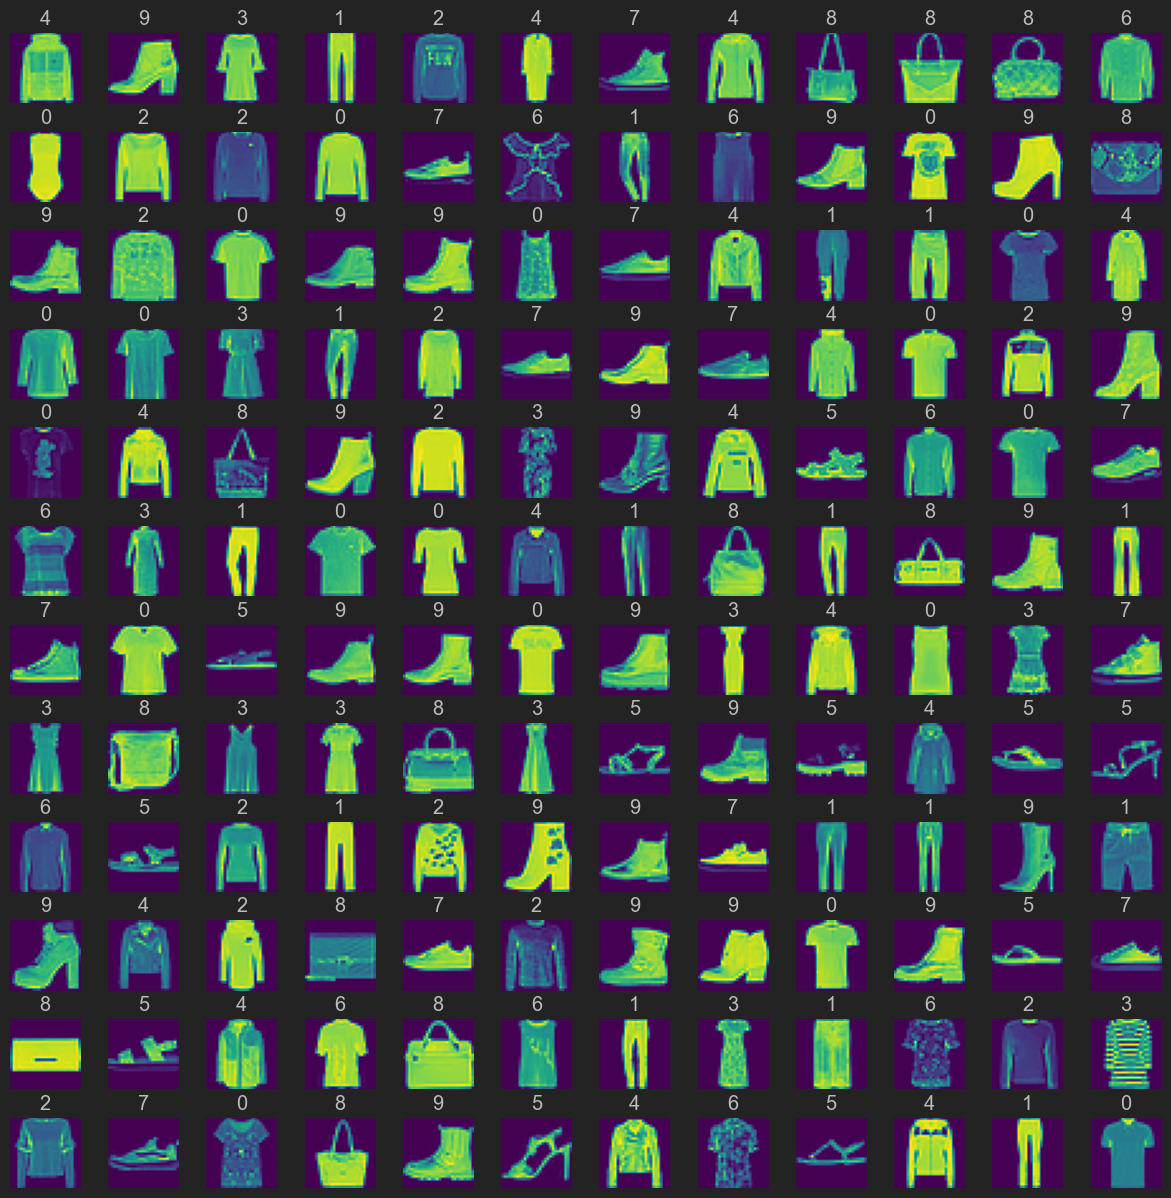

In [45]:
W_grid = 12
L_grid = 12

fig, axes = plt.subplots(L_grid, W_grid, figsize = (15, 15))
axes = axes.ravel()

n_training = len(X_train)

for i in np.arange(0, L_grid * W_grid):
    index = np.random.randint(0, n_training) # pick a random number
    axes[i].imshow(X_train[index])
    axes[i].set_title(y_train[index])
    axes[i].axis('off')
    
plt.subplots_adjust(hspace = 0.4)

# TASK #4: PREPARE THE DATA FOR TRAINING

In [46]:
number_cat = 10
y_train = tf.keras.utils.to_categorical(y_train, number_cat)

In [47]:
X_train.shape

(60000, 28, 28)

In [48]:
y_train.shape

(60000, 10)

In [49]:
y_train

array([[0., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [50]:
X_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [51]:
y_test = tf.keras.utils.to_categorical(y_test, number_cat)

In [52]:
X_train.shape

(60000, 28, 28)

In [53]:
X_train = np.expand_dims(X_train, axis=-1)

In [54]:
X_train.shape

(60000, 28, 28, 1)

In [55]:
y_train.shape

(60000, 10)

# TASK #5: BUILD A DEEP LEARNING MODEL

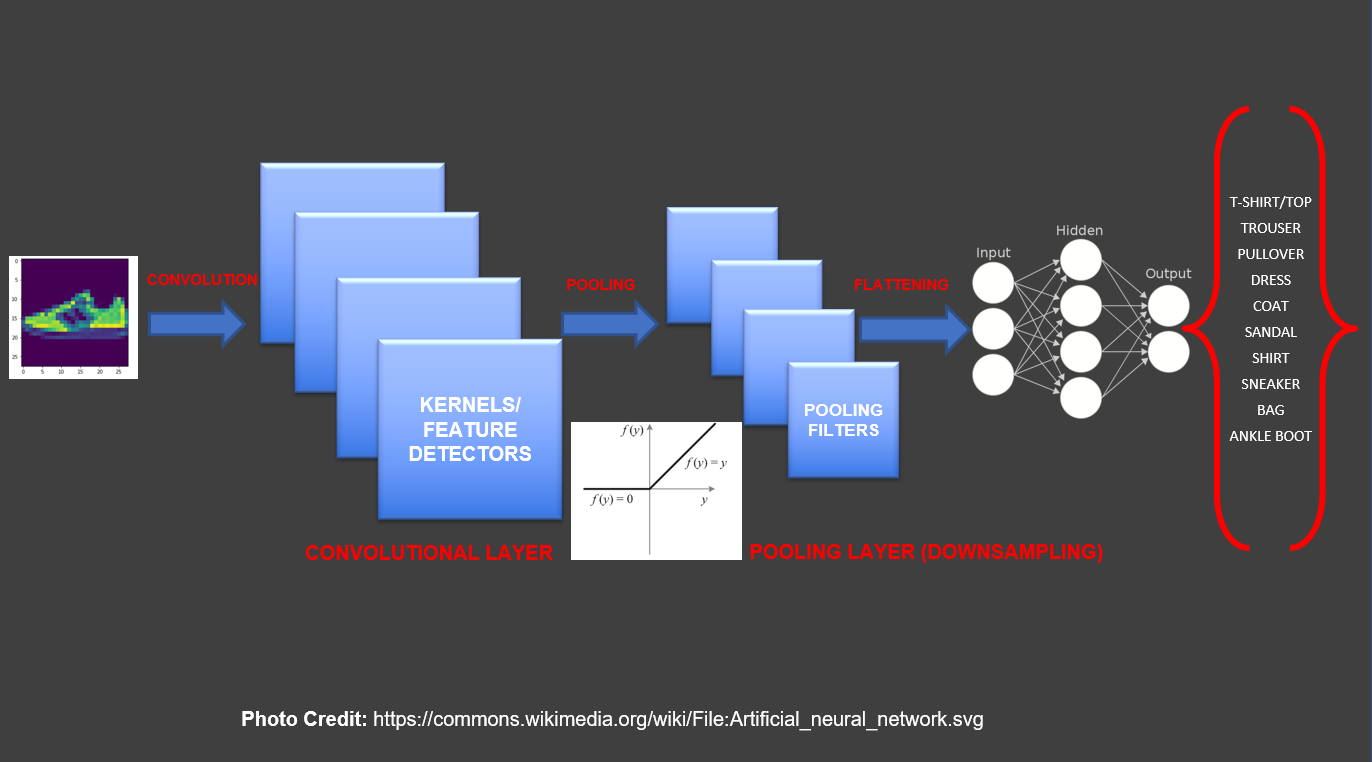

In [56]:
from tensorflow.keras import datasets, layers, models
cnn = models.Sequential()

cnn.add(layers.Conv2D(32, (3,3), activation = 'relu', input_shape = (28, 28, 1)  ))
cnn.add(layers.MaxPooling2D(2,2))

cnn.add(layers.Conv2D(64, (3,3), activation = 'relu' ))
cnn.add(layers.MaxPooling2D(2,2))

cnn.add(layers.Conv2D(64, (3,3), activation = 'relu' ))

cnn.add(layers.Flatten())

cnn.add(layers.Dense(64, activation = 'relu'))
cnn.add(layers.Dense(10, activation = 'softmax'))
cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

# TASK #6: COMPILE AND TRAIN A DEEP LEARNING MODEL

In [57]:
cnn.compile(optimizer = tf.keras.optimizers.RMSprop(0.0001, decay = 1e-6), loss ='categorical_crossentropy', metrics =['accuracy'])

In [58]:
X_train.shape

(60000, 28, 28, 1)

In [59]:
epochs = 10

history = cnn.fit(X_train, y_train, batch_size = 512, epochs = epochs)


Epoch 1/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 11s 83ms/step - accuracy: 0.4497 - loss: 6.3441
Epoch 2/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.7159 - loss: 1.0459
Epoch 3/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step - accuracy: 0.7710 - loss: 0.7290
Epoch 4/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.8020 - loss: 0.5931
Epoch 5/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - accuracy: 0.8190 - loss: 0.5286
Epoch 6/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.8357 - loss: 0.4702
Epoch 7/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.8519 - loss: 0.4276
Epoch 8/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.8524 - loss: 0.4130
Epoch 9/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step - accuracy: 0.8633 - loss: 0.3816
Epoch 10/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.8742 - loss: 0.3552


# TASK #7: ASSESS TRAINED MODEL PERFORMANCE

In [60]:
X_test.shape

(10000, 28, 28)

In [61]:
X_test = np.expand_dims(X_test, axis=-1)

In [62]:
X_test.shape

(10000, 28, 28, 1)

In [63]:
y_test.shape

(10000, 10)

In [64]:
evaluation = cnn.evaluate(X_test, y_test) 

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8503 - loss: 0.4463


In [65]:
X_test = X_test.astype('float')


In [66]:
predicted_classes = cnn.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [67]:
predicted_classes

array([[7.0586644e-08, 3.9453824e-10, 5.6263211e-10, ..., 2.1117884e-03,
        5.0052809e-06, 9.9787748e-01],
       [2.9966023e-07, 3.3130351e-07, 9.9971384e-01, ..., 9.4961004e-11,
        2.6292278e-07, 1.5123208e-10],
       [2.3212371e-11, 1.0000000e+00, 1.2284039e-14, ..., 2.3934160e-17,
        6.4550700e-12, 1.6910744e-11],
       ...,
       [1.6077582e-04, 9.2946340e-10, 2.6129212e-06, ..., 8.4243534e-10,
        9.9973840e-01, 4.6535728e-08],
       [4.6003495e-07, 9.9989831e-01, 6.0220634e-07, ..., 2.5039233e-09,
        1.8488002e-09, 2.8366131e-07],
       [5.4236874e-04, 1.2867107e-05, 4.1033663e-03, ..., 6.9311738e-01,
        4.1726106e-03, 1.4569709e-03]], dtype=float32)

In [68]:
predicted_classes=np.argmax(predicted_classes,axis=1)


In [69]:
predicted_classes

array([9, 2, 1, ..., 8, 1, 7], dtype=int64)

In [70]:
y_test

array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [71]:
y_test = y_test.argmax(1)

In [72]:
y_test

array([9, 2, 1, ..., 8, 1, 5], dtype=int64)

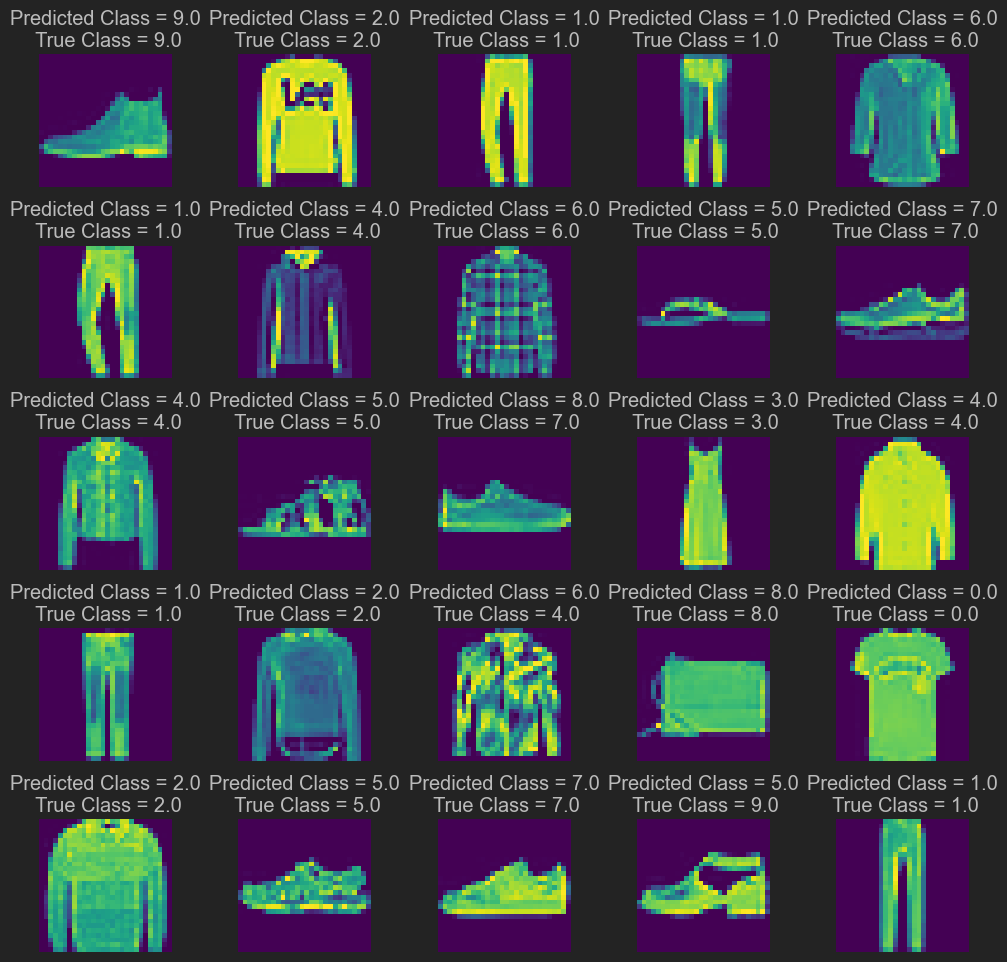

In [73]:
L = 5
W = 5
fig, axes = plt.subplots(L, W, figsize = (12,12))
axes = axes.ravel() # 

for i in np.arange(0, L * W):  
    axes[i].imshow(X_test[i].reshape(28,28))
    axes[i].set_title("Predicted Class = {:0.1f}\n True Class = {:0.1f}".format(predicted_classes[i], y_test[i]))
    axes[i].axis('off')

plt.subplots_adjust(wspace=0.5)

<Axes: >

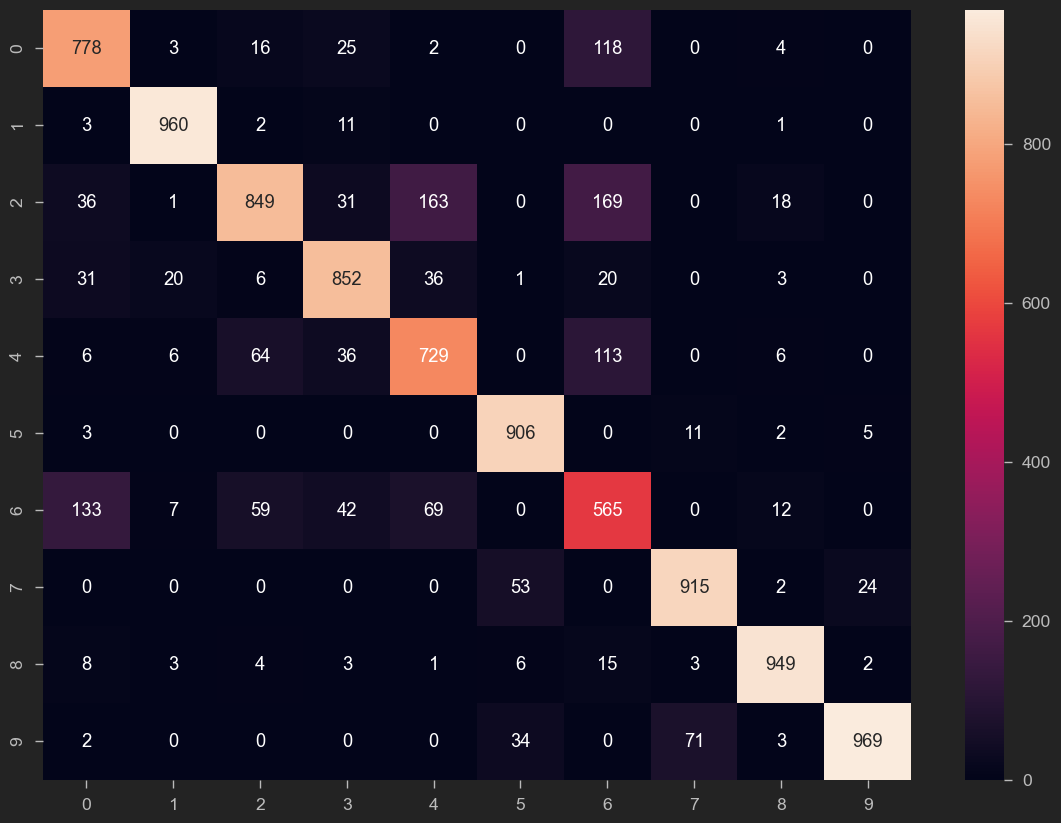

In [74]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(predicted_classes, y_test)
plt.figure(figsize = (14, 10))
sns.heatmap(cm, annot = True, fmt = 'd')

In [75]:
from sklearn.metrics import classification_report

num_classes = 10

target_names = ['class {}'.format(i) for i in range(num_classes)]

print(classification_report(y_test, predicted_classes, target_names = target_names))

              precision    recall  f1-score   support

     class 0       0.82      0.78      0.80      1000
     class 1       0.98      0.96      0.97      1000
     class 2       0.67      0.85      0.75      1000
     class 3       0.88      0.85      0.87      1000
     class 4       0.76      0.73      0.74      1000
     class 5       0.98      0.91      0.94      1000
     class 6       0.64      0.56      0.60      1000
     class 7       0.92      0.92      0.92      1000
     class 8       0.95      0.95      0.95      1000
     class 9       0.90      0.97      0.93      1000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



**PRACTICE OPPORTUNITY #3:**
- **Add a new dense layer containing 1024 neurons**
- **Increase the number of epochs**
- **Plot the model summary and determine the number of trainable parameters**
- **Retrain the model and evaluate its performance**

In [76]:
cnn = models.Sequential()

cnn.add(layers.Conv2D(32, (3,3), activation = 'relu', input_shape = (28, 28, 1)  ))
cnn.add(layers.MaxPooling2D(2,2))

cnn.add(layers.Conv2D(64, (3,3), activation = 'relu' ))
cnn.add(layers.MaxPooling2D(2,2))

cnn.add(layers.Conv2D(64, (3,3), activation = 'relu' ))

cnn.add(layers.Flatten())

cnn.add(layers.Dense(64, activation = 'relu'))
cnn.add(layers.Dense(1024, activation = 'relu'))
cnn.add(layers.Dense(10, activation = 'softmax'))
cnn.summary()

C:\Users\HON\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1024)           │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 169,482 (662.04 KB)

 Trainable params: 169,482 (662.04 KB)

 Non-trainable params: 0 (0.00 B)

In [77]:
cnn.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.0001, decay=1e-6), loss='categorical_crossentropy', metrics=['accuracy'])

C:\Users\HON\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\optimizers\base_optimizer.py:33: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [78]:
epochs = 20

history = cnn.fit(X_train, y_train, batch_size = 512, epochs = epochs)

Epoch 1/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 11s 83ms/step - accuracy: 0.5782 - loss: 1.4839
Epoch 2/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.7852 - loss: 0.5749
Epoch 3/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - accuracy: 0.8173 - loss: 0.4950
Epoch 4/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - accuracy: 0.8343 - loss: 0.4528
Epoch 5/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - accuracy: 0.8505 - loss: 0.4109
Epoch 6/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - accuracy: 0.8596 - loss: 0.3864
Epoch 7/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - accuracy: 0.8673 - loss: 0.3581
Epoch 8/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - accuracy: 0.8733 - loss: 0.3481
Epoch 9/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.8817 - loss: 0.3243
Epoch 10/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - accuracy: 0.8828 - loss: 0.3153
Epoch 11/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - accuracy: 0.8884 - loss: 0.3024
Epoch 12/20
118/118 ━━━━━━━━━━━━━━━━━

In [79]:
X_test.shape

(10000, 28, 28, 1)

In [80]:
X_test = np.expand_dims(X_test, axis=-1)

In [81]:
X_test.shape

(10000, 28, 28, 1, 1)

In [82]:
y_test.shape

(10000,)

In [83]:
X_test = X_test.astype('float')


In [84]:
predicted_classes = cnn.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [85]:
predicted_classes

array([[1.6648359e-07, 2.7721741e-08, 2.9096002e-06, ..., 4.3435870e-03,
        1.5304489e-05, 9.9530542e-01],
       [3.6506663e-05, 5.9746919e-10, 9.9995315e-01, ..., 1.7452948e-12,
        1.1750715e-06, 1.6261444e-13],
       [2.5672700e-10, 1.0000000e+00, 7.9096946e-10, ..., 1.1467130e-12,
        5.7945298e-11, 1.4746339e-13],
       ...,
       [3.3101912e-07, 1.9035386e-11, 7.1050829e-07, ..., 6.7840691e-11,
        9.9999750e-01, 1.9623510e-13],
       [2.4099316e-07, 9.9997652e-01, 2.6053685e-06, ..., 2.6967834e-10,
        5.0728408e-07, 2.1642788e-10],
       [5.3685455e-04, 2.0347792e-05, 8.9262091e-03, ..., 7.4347347e-01,
        1.2965795e-01, 5.0005951e-04]], dtype=float32)

In [86]:
predicted_classes=np.argmax(predicted_classes,axis=1)

In [87]:
predicted_classes

array([9, 2, 1, ..., 8, 1, 7], dtype=int64)

In [88]:
y_test

array([9, 2, 1, ..., 8, 1, 5], dtype=int64)

In [89]:
y_test = y_test.argmax(1)

AxisError: axis 1 is out of bounds for array of dimension 1

In [ ]:
y_test

In [ ]:

cm = confusion_matrix(predicted_classes, y_test)
plt.figure(figsize = (14, 10))
sns.heatmap(cm, annot = True, fmt = 'd')

In [ ]:

num_classes = 10
target_names = ['class {}'.format(i) for i in range(num_classes)]

print(classification_report(y_test, predicted_classes, target_names = target_names))

# GREAT JOB!

# PRACTICE OPPORTUNITIES SOLUTIONS 

**PRACTICE OPPORTUNITY #1 SOLUTION:**
- **Check out the sizes of both training and testing datasets**

In [ ]:
X_train.shape

(60000, 28, 28, 1)

In [ ]:
X_test.shape

(10000, 28, 28, 1)

In [ ]:
y_train.shape

(60000, 10)

In [ ]:
y_test.shape

(10000,)

**PRACTICE OPPORTUNITY #2 SOLUTION:**
- **Plot a grid containing 144 images and perform a sanity check on the data** 

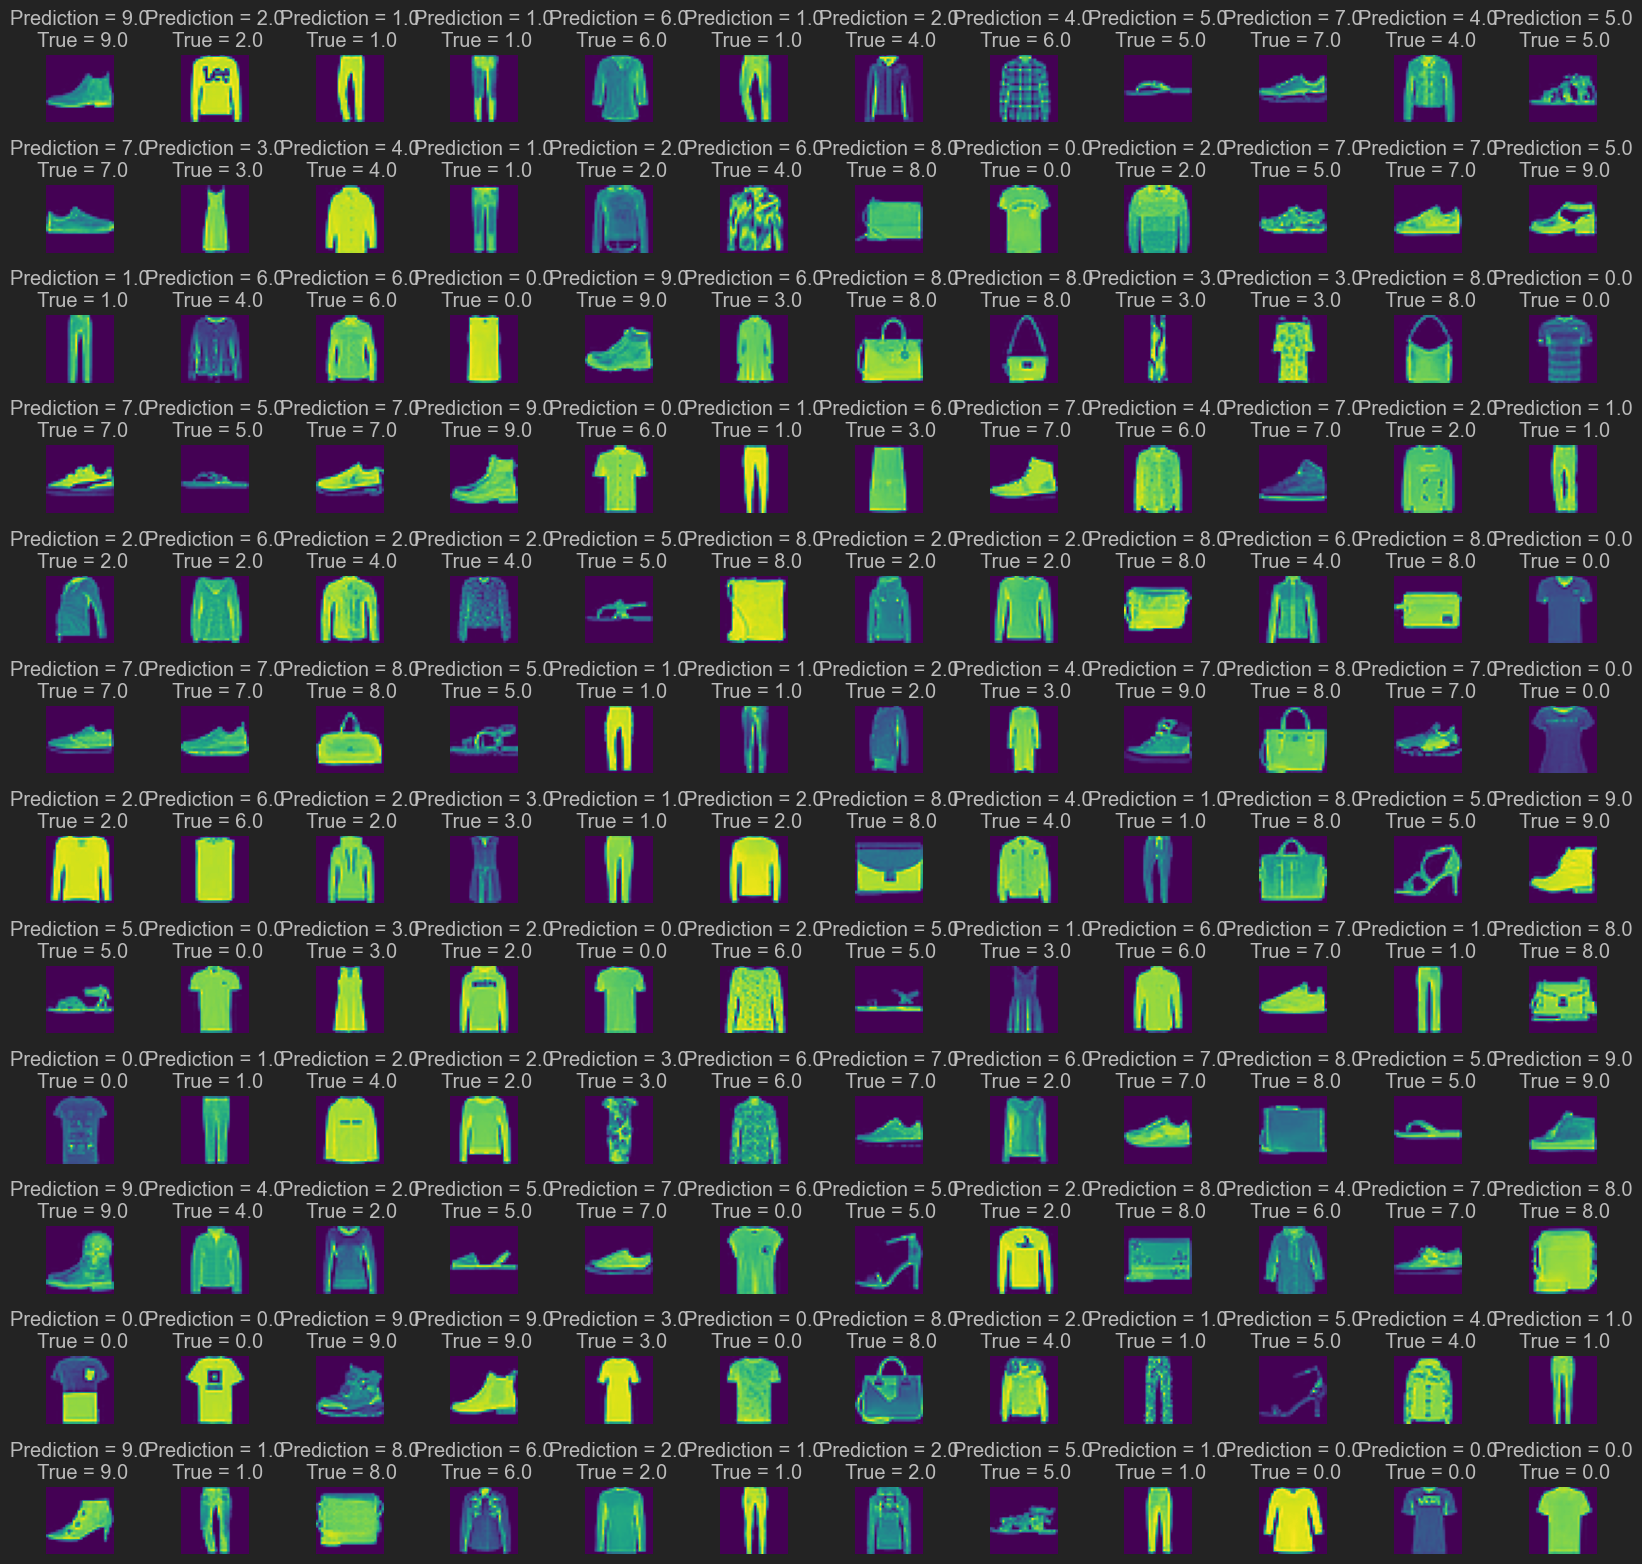

In [ ]:
L = 12
W = 12
fig, axes = plt.subplots(L, W, figsize = (20,20))
axes = axes.ravel() 

for i in np.arange(0, L * W):  
    axes[i].imshow(X_test[i].reshape(28,28))
    axes[i].set_title("Prediction = {:0.1f}\n True = {:0.1f}".format(predicted_classes[i], y_test[i]))
    axes[i].axis('off')

plt.subplots_adjust(wspace=1)

**PRACTICE OPPORTUNITY #3 SOLUTION:**
- **Add a new dense layer containing 1024 neurons**
- **Increase the number of epochs**
- **Plot the model summary and determine the number of trainable parameters**
- **Retrain the model and evaluate its performance**

In [ ]:
from tensorflow.keras import datasets, layers, models
cnn = models.Sequential()

cnn.add(layers.Conv2D(32, (3,3), activation = 'relu', input_shape = (28, 28, 1)  ))
cnn.add(layers.MaxPooling2D(2,2))

cnn.add(layers.Conv2D(64, (3,3), activation = 'relu' ))
cnn.add(layers.MaxPooling2D(2,2))

cnn.add(layers.Conv2D(64, (3,3), activation = 'relu' ))

cnn.add(layers.Flatten())

cnn.add(layers.Dense(1024, activation = 'relu'))
cnn.add(layers.Dense(64, activation = 'relu'))
cnn.add(layers.Dense(10, activation = 'softmax'))
cnn.summary()

C:\Users\HON\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_27 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1024)           │       590,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 712,842 (2.72 MB)

 Trainable params: 712,842 (2.72 MB)

 Non-trainable params: 0 (0.00 B)